In [3]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [4]:
from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


save_path = "/Users/niaggar/Results"
folder = "study_rgd_vs_mie_rgd_limit_SAME_Ls__PLIN"

In [5]:
import pathlib
FIGDIR = pathlib.Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

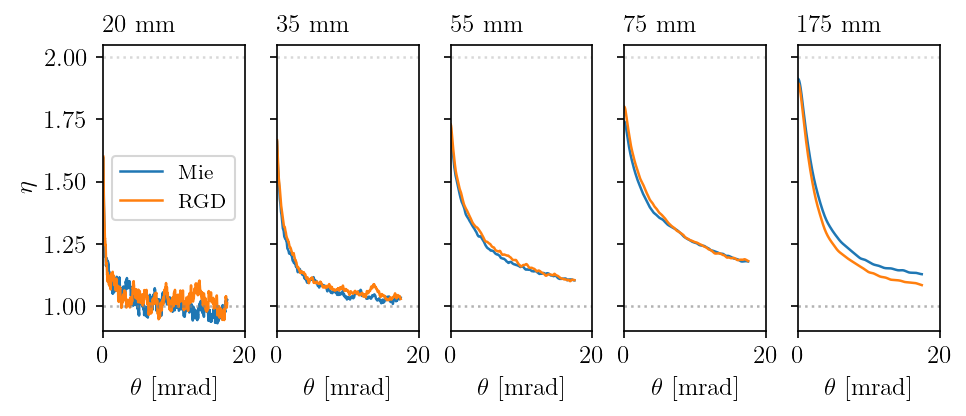

In [8]:
# ---------------------------------------------------------------------------
# Carga: agrupar por radio, separando modelo (rgd / mie) por el sufijo del run
# ---------------------------------------------------------------------------
sweep_data = load_sweep(folder, base_path=Path(save_path))

data = {}   # data[radius] = {"mie": prof, "rgd": prof}
for name, loader in sweep_data.items():
    if name.endswith("_mie"):
        model = "mie"
    elif name.endswith("_rgd"):
        model = "rgd"
    else:
        continue

    radius = loader.params.layers[0].medium.radius
    prof = cbs_profiles(
        loader.processed_cbs("farfield_cbs"),
        basis=linear, time_index=0, reduce=keep,
    )
    data.setdefault(radius, {})[model] = prof

radii = sorted(data)
ncol = len(radii)




apply(width_frac=1.0)
fig, axes = plt.subplots(1, ncol, figsize=(TEXTWIDTH_IN, 0.42*TEXTWIDTH_IN), sharey=True)

if ncol == 1:
    axes = [axes]

for ax, radius in zip(axes, radii):
    d = data[radius]

    if "mie" in d:
        th = d["mie"].theta * 1e3
        x_0 = d["mie"].enhancement["co"][:, 0]
        ax.plot(th, x_0, color="C0", ls="-",  label="Mie")
    if "rgd" in d:
        th = d["rgd"].theta * 1e3
        x_0 = d["rgd"].enhancement["co"][:, 0]
        ax.plot(th, x_0, color="C1", ls="-",  label="RGD")

    ax.axhline(1.0, color="gray", ls=":", alpha=0.6)
    ax.axhline(2.0, color="gray", ls=":", alpha=0.3)
    ax.set_xlim(0, 20)
    ax.set_ylim(0.9, 2.05)
    ax.set_xlabel(r"$\theta$ [mrad]")
    ax.set_title(fr"${(radius * 1000):.0f}$ mm", loc="left")

axes[0].set_ylabel(r"$\eta$")
axes[0].legend(fontsize="small")
fig.savefig(Path(save_path) / folder / "cbs_rgd_vs_mie_copol.png", dpi=200)
plt.show()





# fig, axes = plt.subplots(1, ncol, figsize=(3.2 * ncol, 3.4), sharey=True)
# if ncol == 1:
#     axes = [axes]

# for ax, radius in zip(axes, radii):
#     d = data[radius]

#     if "mie" in d:
#         th = d["mie"].theta * 1e3
#         y_90 = d["mie"].enhancement["co"][:, 9]
#         ax.plot(th, y_90, color="C0", ls="-",  label="Mie")
#     if "rgd" in d:
#         th = d["rgd"].theta * 1e3
#         y_90 = d["rgd"].enhancement["co"][:, 9]
#         ax.plot(th, y_90, color="C1", ls="-",  label="RGD")

#     ax.axhline(1.0, color="gray", ls=":", alpha=0.6)
#     ax.axhline(2.0, color="gray", ls=":", alpha=0.3)
#     ax.set_xlim(0, 20)
#     ax.set_ylim(0.9, 2.05)
#     ax.set_xlabel("Angulo (mrad)")
#     ax.set_title(fr"$a = {radius:.3f}\,\mu m$")

# axes[0].set_ylabel("Realce co-pol")
# axes[0].legend(fontsize="small")
# fig.suptitle(r"CBS lineal co-pol: RGD vs Mie (mismo $l_s$)")
# fig.tight_layout()
# fig.savefig(Path(save_path) / folder / "cbs_rgd_vs_mie_copol.png", dpi=200)
# plt.show()

In [9]:
from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd

@dataclass
class Grouped:
    name: str
    radius: float
    replicas_keys: list[str]

In [46]:
save_path = "/Users/niaggar/Results"

radius_values = [0.020, 0.035, 0.055, 0.075, 0.100, 0.175]
N_MEDIUM = 1.33
N_PARTICLE = 1.59
WAVELENGTH = 0.514 
k = 2 * np.pi * N_MEDIUM / WAVELENGTH
N_REPLICAS = 5

data_names = []
for rep in range(N_REPLICAS):
    for index, rad in enumerate(radius_values):
        name = f"radius_{rad:.3f}__rep{rep}"
        val = index * N_REPLICAS + rep
        full_name = f"{val:04d}_{name}"
        data_names.append((full_name, rf"{rad*1000:.0f} nm"))

print(data_names)

[('0000_radius_0.020__rep0', '20 nm'), ('0005_radius_0.035__rep0', '35 nm'), ('0010_radius_0.055__rep0', '55 nm'), ('0015_radius_0.075__rep0', '75 nm'), ('0020_radius_0.100__rep0', '100 nm'), ('0025_radius_0.175__rep0', '175 nm'), ('0001_radius_0.020__rep1', '20 nm'), ('0006_radius_0.035__rep1', '35 nm'), ('0011_radius_0.055__rep1', '55 nm'), ('0016_radius_0.075__rep1', '75 nm'), ('0021_radius_0.100__rep1', '100 nm'), ('0026_radius_0.175__rep1', '175 nm'), ('0002_radius_0.020__rep2', '20 nm'), ('0007_radius_0.035__rep2', '35 nm'), ('0012_radius_0.055__rep2', '55 nm'), ('0017_radius_0.075__rep2', '75 nm'), ('0022_radius_0.100__rep2', '100 nm'), ('0027_radius_0.175__rep2', '175 nm'), ('0003_radius_0.020__rep3', '20 nm'), ('0008_radius_0.035__rep3', '35 nm'), ('0013_radius_0.055__rep3', '55 nm'), ('0018_radius_0.075__rep3', '75 nm'), ('0023_radius_0.100__rep3', '100 nm'), ('0028_radius_0.175__rep3', '175 nm'), ('0004_radius_0.020__rep4', '20 nm'), ('0009_radius_0.035__rep4', '35 nm'), ('0

In [20]:
# rgd
folder_rgd_lineal = "study_homog_timeresolved__PLIN__beam2500"
sweep_data_rgd_lineal = load_sweep(folder_rgd_lineal, base_path=Path(save_path))

data_keys = list(sweep_data_rgd_lineal.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")

# mie
folder_mie_lineal = "study_mie_same_Ls__PLIN__beam2500"
sweep_data_mie_lineal = load_sweep(folder_mie_lineal, base_path=Path(save_path))

data_keys = list(sweep_data_mie_lineal.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


grouped_data = []
for rad in radius_values:
    replicas_keys = [key for key, _ in data_names if f"radius_{rad:.3f}" in key]
    grouped = Grouped(radius=rad, replicas_keys=replicas_keys, name=rf"{rad*1000:.0f} nm")
    grouped_data.append(grouped)

print(grouped_data)

Loaded 30 datasets: ['0012_radius_0.055__rep2', '0021_radius_0.100__rep1', '0001_radius_0.020__rep1', '0016_radius_0.075__rep1', '0025_radius_0.175__rep0', '0007_radius_0.035__rep2', '0009_radius_0.035__rep4', '0015_radius_0.075__rep0', '0026_radius_0.175__rep1', '0023_radius_0.100__rep3', '0010_radius_0.055__rep0', '0005_radius_0.035__rep0', '0027_radius_0.175__rep2', '0019_radius_0.075__rep4', '0003_radius_0.020__rep3', '0014_radius_0.055__rep4', '0029_radius_0.175__rep4', '0017_radius_0.075__rep2', '0006_radius_0.035__rep1', '0028_radius_0.175__rep3', '0002_radius_0.020__rep2', '0011_radius_0.055__rep1', '0022_radius_0.100__rep2', '0018_radius_0.075__rep3', '0004_radius_0.020__rep4', '0024_radius_0.100__rep4', '0008_radius_0.035__rep3', '0000_radius_0.020__rep0', '0020_radius_0.100__rep0', '0013_radius_0.055__rep3']
Loaded 30 datasets: ['0012_radius_0.055__rep2', '0021_radius_0.100__rep1', '0001_radius_0.020__rep1', '0016_radius_0.075__rep1', '0025_radius_0.175__rep0', '0007_radius_

In [ ]:
eps = 1e-30

def load_stitched(channel, k, lstar, th1, g1, th2, g2, key):
    theta_1 = th1[-1]                       # fin de la ventana fina
    lo = 0.9 * theta_1                       # inicio real de det_2 (solape)

    # --- chequeo de stitching: interpola det_1 sobre los bins de solape de det_2
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > 0.05:            # umbral: 5% del enhancement
            print(f"[stitch WARN] {key} ch={channel}: max solape "
                  f"{np.max(resid):.3f} -- revisar normalizacion angulo solido")

    # une: det_1 completo + det_2 estrictamente por encima de theta_1
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    q = k * lstar * theta
    return theta, q, g

def tail_baseline(q, y, q_min=25.0, n_min=5, frac=0.85):
    """Fondo en la cola, inmune a ventanas vacías.
    Usa q>q_min si hay puntos suficientes; si no, cae al tramo alto
    del q realmente disponible para ese radio."""
    q = np.asarray(q); y = np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    q_cut = frac * np.nanmax(q)          # último ~15 % del q disponible
    m = q >= q_cut
    if np.count_nonzero(m) < n_min:
        idx = np.argsort(q)[-n_min:]     # los n_min puntos de mayor q
        return np.median(y[idx])
    return np.median(y[m])

def load_mean_enhancement(sweep_data, grouped_rad, basis, reduce, time_index, chanel, k):
    I_incoherent_total_1 = None
    I_incoherent_total_2 = None
    I_coherent_total_1 = None
    I_coherent_total_2 = None
    for key in grouped_rad.replicas_keys:
        sweep = sweep_data[key]

        p1 = cbs_profiles(sweep.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
        p2 = cbs_profiles(sweep.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)

        if I_incoherent_total_1 is None:
            I_incoherent_total_1 = np.zeros_like(p1.incoherent[chanel])
            I_incoherent_total_2 = np.zeros_like(p2.incoherent[chanel])
            I_coherent_total_1 = np.zeros_like(p1.coherent[chanel])
            I_coherent_total_2 = np.zeros_like(p2.coherent[chanel])

        I_incoherent_total_1 = I_incoherent_total_1 + p1.incoherent[chanel]
        I_incoherent_total_2 = I_incoherent_total_2 + p2.incoherent[chanel]
        I_coherent_total_1 = I_coherent_total_1 + p1.coherent[chanel]
        I_coherent_total_2 = I_coherent_total_2 + p2.coherent[chanel]

    enhancement_1 = (I_coherent_total_1 + eps) / (I_incoherent_total_1 + eps)
    enhancement_2 = (I_coherent_total_2 + eps) / (I_incoherent_total_2 + eps)
    sweep0 = sweep_data[grouped_rad.replicas_keys[0]]
    p0_1 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
    p0_2 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)
    theta_1 = p0_1.theta
    theta_2 = p0_2.theta

    lstar0 = sweep_data[grouped_rad.replicas_keys[0]].params_flat["transport_mean_free_path"]
    theta, q, enhancement = load_stitched(chanel, k, lstar0, theta_1, enhancement_1, theta_2, enhancement_2, grouped_rad.replicas_keys[0])

    return theta, q, enhancement

def profile_one(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """Perfil E(q) de UNA replica, baseline llevada a 1."""
    reducer = phi_cut(phi_index) if basis == linear else azimuthal_average
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=basis,
                      time_index=time_index, reduce=reducer)
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=basis,
                      time_index=time_index, reduce=reducer)
    E1 = (p1.coherent[channel] + eps) / (p1.incoherent[channel] + eps)
    E2 = (p2.coherent[channel] + eps) / (p2.incoherent[channel] + eps)
    
    lst = 0
    if "transport_mean_free_path" in sw.params_flat:
        lst = sw.params_flat["transport_mean_free_path"]
    else:
        lst = sw.params_flat.get("lstar_sim", 0.0)

    theta, q, E = load_stitched(channel, k, lst, p1.theta, E1, p2.theta, E2, key)
    return theta, q, E - tail_baseline(q, E) + 1.0

def profile_stats(sweep, grouped_rad, phi_index, channel, time_index=0, basis=linear):
    """Media y desviacion estandar (ddof=1) sobre las replicas."""
    curves = []
    for key in grouped_rad.replicas_keys:
        theta, q, E = profile_one(sweep, key, phi_index, channel, time_index=time_index, basis=basis)
        curves.append(E)
    C = np.vstack(curves)
    return theta, q, C.mean(axis=0), C.std(axis=0, ddof=1)

def mirror(q, *ys):
    """Espejo -q..+q para presentacion estilo Iwai (valido: I(th,phi)=I(th,phi+pi))."""
    return (np.r_[-q[::-1], q],) + tuple(np.r_[y[::-1], y] for y in ys)

In [17]:
sweep_mie = sweep_data_mie_lineal["0000_radius_0.020__rep0"]
print(sweep_mie.params_flat)

{'d_phi': 0.17453292519943295, 'd_theta_1': 2.0635645226778435e-06, 'd_theta_2': 4.402270981712732e-05, 'd_time': 223.55007520015556, 'g_mie': 0.017315882477824857, 'g_rgd': 0.01707798707335239, 'grid_anchor': 'lstar_rgd (fixed-lab)', 'laser_radius_um': 2500, 'laser_sigma': 2500.0, 'laser_source_type': 'Gaussian', 'layer_kind': 'homogeneous', 'ls_fixed_from_rgd': 549.3307247641008, 'lstar_ratio_sim_over_ref': 1.0002420873607607, 'lstar_rgd_ref': 558.8751880003888, 'lstar_sim': 559.0104846196465, 'max_events': 1000, 'mean_free_path': 549.3307247641008, 'medium_kind': 'MieMedium', 'mu_a': 0.0, 'mu_s': 1.0, 'mu_t': 1.0, 'n_layers': 1, 'n_medium': 1.33, 'n_particle': 1.59, 'n_phi': 36, 'n_photons': 300000, 'n_theta_1': 400, 'n_theta_2': 100, 'n_threads': 46, 'polarization': 'linear', 'q_fine': 7.5, 'q_tail': 40.0, 'radius': 0.02, 'replica': 0, 'sample_n_medium': 1.33, 'scattering_model': 'mie', 'seed': 20260713, 'study_invariant': 'ls_fixed', 't_max': 22355.007520015555, 'tau_star_fs': 247

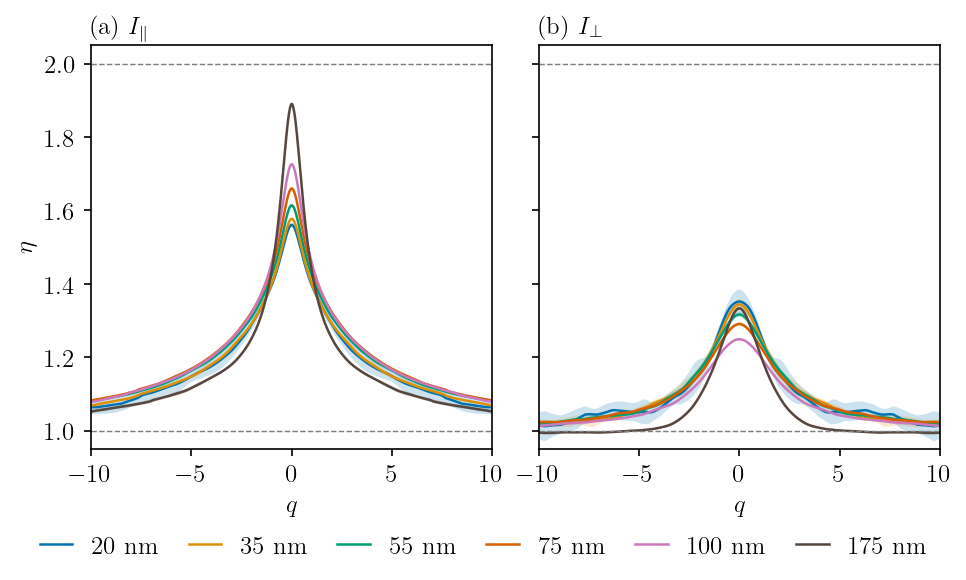

In [24]:
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.6*TEXTWIDTH_IN), sharey=True)

for c, g_ in zip(COL, grouped_data):
    for ax, ch in ((ax1, "co"), (ax2, "cross")):
        theta, q, m, s = profile_stats(sweep_data_mie_lineal, g_, 0, ch)          # phi = 0 (X-scan)
        qs, ms, ss = mirror(q, m, s)
        ax.plot(qs, ms, color=c, label=g_.name)
        ax.fill_between(qs, ms - ss, ms + ss, color=c, alpha=0.20, lw=0)

for ax, t in ((ax1, r"(a) $I_\parallel$"), (ax2, r"(b) $I_\perp$")):
    ax.set_xlim(-10, 10);
    ax.set_ylim(0.95, 2.05)
    ax.set_xlabel(r"$q$")
    ax.set_title(t, loc="left")
    ax.axhline(2.0, ls="--", c="gray", lw=0.7)
    ax.axhline(1.0, ls="--", c="gray", lw=0.7)

ax1.set_ylabel(r"$\eta$")
fig.legend(*ax1.get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_perfiles_co_cross_q_phi00.pdf")

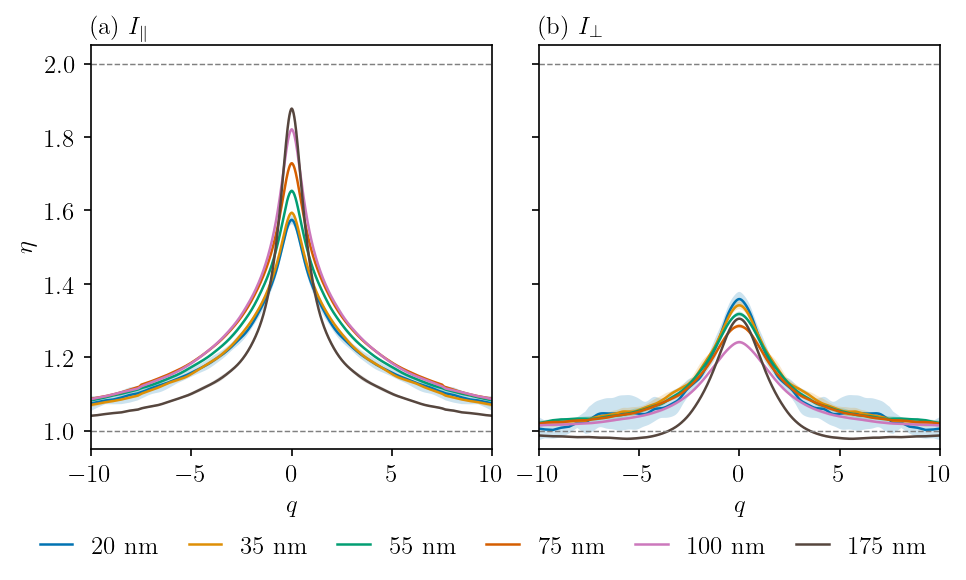

In [25]:
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.6*TEXTWIDTH_IN), sharey=True)

for c, g_ in zip(COL, grouped_data):
    for ax, ch in ((ax1, "co"), (ax2, "cross")):
        theta, q, m, s = profile_stats(sweep_data_rgd_lineal, g_, 0, ch)          # phi = 0 (X-scan)
        qs, ms, ss = mirror(q, m, s)
        ax.plot(qs, ms, color=c, label=g_.name)
        ax.fill_between(qs, ms - ss, ms + ss, color=c, alpha=0.20, lw=0)

for ax, t in ((ax1, r"(a) $I_\parallel$"), (ax2, r"(b) $I_\perp$")):
    ax.set_xlim(-10, 10);
    ax.set_ylim(0.95, 2.05)
    ax.set_xlabel(r"$q$")
    ax.set_title(t, loc="left")
    ax.axhline(2.0, ls="--", c="gray", lw=0.7)
    ax.axhline(1.0, ls="--", c="gray", lw=0.7)

ax1.set_ylabel(r"$\eta$")
fig.legend(*ax1.get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_perfiles_co_cross_q_phi00.pdf")

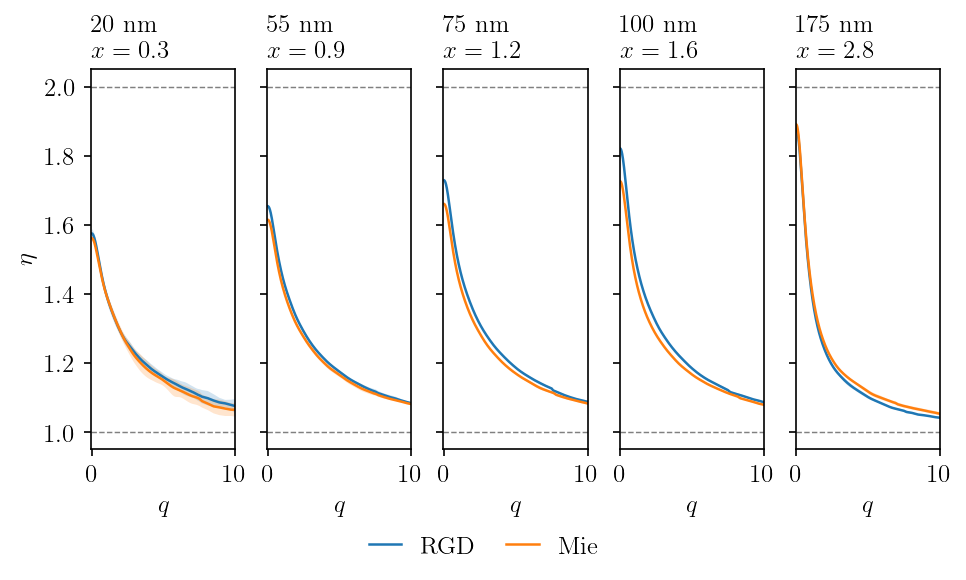

In [55]:
radius_study = [0.020, 0.055, 0.075, 0.100, 0.175]
grouped_data_study = []
for rad in radius_study:
    replicas_keys = [key for key, _ in data_names if f"radius_{rad:.3f}" in key]
    grouped = Grouped(radius=rad, replicas_keys=replicas_keys, name=rf"{rad*1000:.0f} nm")
    grouped_data_study.append(grouped)


apply(width_frac=1.0)
fig, axes = plt.subplots(1, len(radius_study), figsize=(TEXTWIDTH_IN, 0.6*TEXTWIDTH_IN), sharey=True)

for ax, g_ in zip(axes, grouped_data_study):
    theta, q, m, s = profile_stats(sweep_data_rgd_lineal, g_, 0, "co")          # phi = 0 (X-scan)
    # qs, ms, ss = mirror(q, m, s)
    ax.plot(q, m, label="RGD")
    ax.fill_between(q, m - s, m + s, alpha=0.20, lw=0)

    thetam, qm, mm, sm = profile_stats(sweep_data_mie_lineal, g_, 0, "co")          # phi = 0 (X-scan)
    # qsm, msm, ssm = mirror(qm, mm, sm)
    ax.plot(qm, mm, label="Mie")
    ax.fill_between(qm, mm - sm, mm + sm, alpha=0.20, lw=0)

    size_parameter = k * g_.radius

    ax.set_title(fr"${(g_.radius * 1000):.0f}$ nm" + "\n" + fr"$x={size_parameter:.1f}$", loc="left")

for ax in axes:
    ax.set_xlim(-0.05, 10);
    ax.set_ylim(0.95, 2.05)
    ax.set_xlabel(r"$q$")
    ax.axhline(2.0, ls="--", c="gray", lw=0.7)
    ax.axhline(1.0, ls="--", c="gray", lw=0.7)

axes[0].set_ylabel(r"$\eta$")
fig.legend(*axes[0].get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_perfiles_co_cross_q_phi00.pdf")

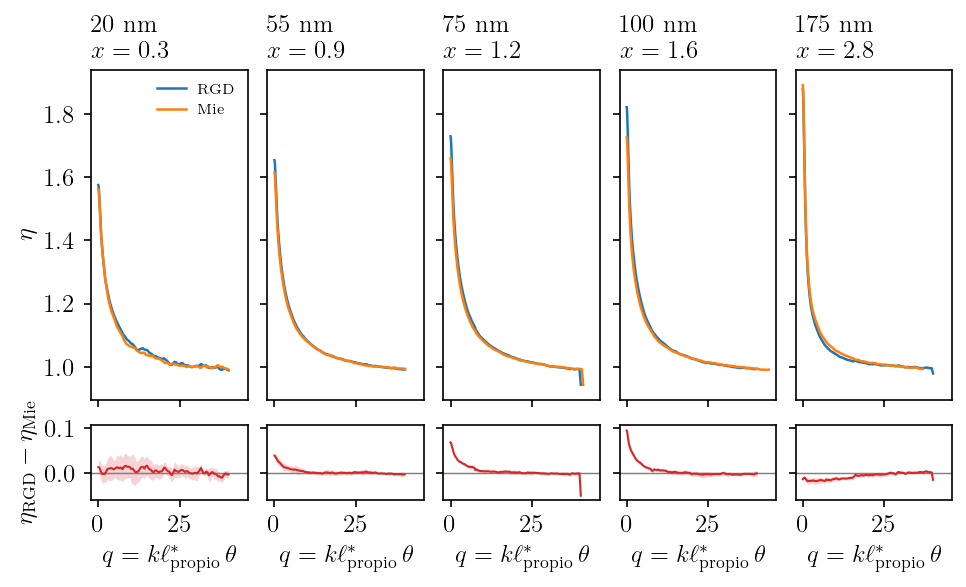

In [60]:
fig, axes = plt.subplots(2, len(radius_study), figsize=(TEXTWIDTH_IN, 0.6*TEXTWIDTH_IN),
                         sharey="row", sharex=True, height_ratios=[2.2, 0.5])

for j, g_ in enumerate(radius_study_grouped := grouped_data_study):
    t1, q1, m1, s1 = profile_stats(sweep_data_rgd_lineal, g_, 0, "co")
    t2, q2, m2, s2 = profile_stats(sweep_data_mie_lineal, g_, 0, "co")
    m2i = np.interp(q1, q2, m2); s2i = np.interp(q1, q2, s2)

    ax = axes[0, j]
    ax.plot(q1, m1, label="RGD"); ax.plot(q2, m2, label="Mie")
    # ax.set_title(fr"${g_.radius*1e3:.0f}$ nm, $x={k*g_.radius:.1f}$", loc="left", fontsize=8)
    ax.set_title(fr"${(g_.radius * 1000):.0f}$ nm" + "\n" + fr"$x={k*g_.radius:.1f}$", loc="left")

    axd = axes[1, j]
    d, sd = m1 - m2i, np.sqrt(s1**2 + s2i**2)
    axd.axhline(0, c="gray", lw=0.7)
    axd.plot(q1, d, color="C3", lw=1.0)
    axd.fill_between(q1, d - sd, d + sd, color="C3", alpha=0.2, lw=0)
    axd.set_xlabel(r"$q = k\ell^*_{\rm propio}\,\theta$")

axes[1, 0].set_ylabel(r"$\eta_{\rm RGD}-\eta_{\rm Mie}$")
axes[0, 0].set_ylabel(r"$\eta$"); axes[0, 0].legend(frameon=False, fontsize=7)
fig.savefig(FIGDIR / "cbs_mie_vs_rgd_lineal.pdf")

In [47]:
# ---- g, l* y peso de retro de ambos kernels, radio a radio -------------------
# Todo sale de derived_quantities (ya en tus params) + una integral 1D de p(theta).
from scipy.integrate import simpson
from luminis_mc import (
    RGDMedium, MieMedium, RayleighDebyeEMCPhaseFunction, MiePhaseFunction
)

def kernel_metrics(radius, n_p, n_med, wl, ndiv=100_000):
    """g, l*/l_s y p(180) normalizado para RGD y Mie a l_s fijo."""
    th = np.linspace(1e-6, np.pi, ndiv)
    out = {}
    for name, PF in (("rgd", RayleighDebyeEMCPhaseFunction),
                     ("mie", MiePhaseFunction)):
        pf = PF(wl, radius, n_p, n_med, ndiv, 0.0, np.pi)
        p  = np.array([pf.rho_phase_function(t) for t in th])   # p(theta), ya ~normalizada
        norm = simpson(p*np.sin(th), th)
        g   = simpson(p*np.cos(th)*np.sin(th), th) / norm
        p180 = p[-1] / norm                                     # peso relativo de retro
        out[name] = dict(g=g, inv_1mg=1.0/(1.0-g), p180=p180)
    r = out["rgd"]; m = out["mie"]
    return dict(
        x        = k*radius,
        rho_p    = 2*k*radius*abs(n_p/n_med - 1),        # tu criterio del Cap.2
        g_rgd    = r["g"],  g_mie = m["g"],
        lstar_ratio = (1-m["g"])/(1-r["g"]),                   # = l*_RGD / l*_Mie
        p180_ratio  = r["p180"]/m["p180"],                     # >1 => RGD predice MAS retro
    )

rows = [kernel_metrics(g_.radius, N_PARTICLE, N_MEDIUM, WAVELENGTH)
        for g_ in grouped_data_study]
import pandas as pd
dfk = pd.DataFrame(rows, index=[f"{g_.radius*1e3:.0f}" for g_ in grouped_data_study])
dfk.round(3)

,x,rho_p,g_rgd,g_mie,lstar_ratio,p180_ratio
20,0.325,0.127,0.017,0.018,0.999,1.002
35,0.569,0.222,0.053,0.056,0.997,1.006
55,0.894,0.350,0.133,0.140,0.992,1.014
75,1.219,0.477,0.250,0.267,0.978,1.048
100,1.626,0.636,0.437,0.484,0.918,1.403
175,2.845,1.112,0.785,0.764,1.094,0.569


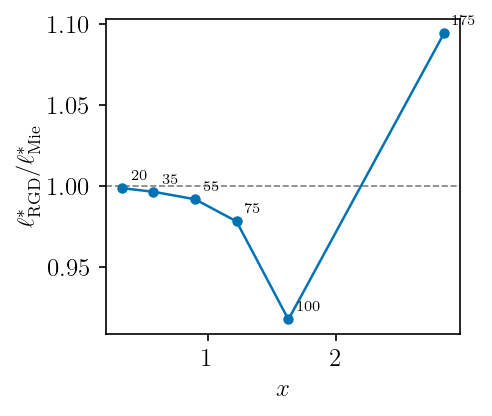

In [68]:
from scipy.optimize import curve_fit

B = 0.7104   # z0/l*, condicion de contorno de Milne

def cone_shape(x, b=B):
    """Cono difusivo normalizado (Akkermans et al. 1986). C(0) = 1."""
    x = np.maximum(np.asarray(x, float), 1e-9)
    return (1.0/(1.0 + 2.0*b)) / (1.0 + x)**2 * (1.0 + (1.0 - np.exp(-2.0*b*x)) / x)

def fit_cone(q, E, q_max=6.0):
    """Ajusta E(q) = 1 + A * C(r*q).

    q  = k * l*_teo * theta   (reducido con el l* teorico)
    r  = l*_med / l*_teo      (parametro libre: el reescalado del ancho)
    A  = amplitud del pico    (A = eta(0) - 1)

    Devuelve (r, A). No hay ninguna constante calibrada aqui: r es la
    razon cruda entre el ancho medido y el ancho difusivo esperado.
    """
    q = np.asarray(q, float); E = np.asarray(E, float)
    m = (q < q_max) & np.isfinite(E)
    popt, _ = curve_fit(lambda qq, r, A: 1.0 + A * cone_shape(r * qq),
                        q[m], E[m], p0=[1.0, 1.0],
                        bounds=([0.02, 0.0], [50.0, 1.2]), maxfev=20000)
    return popt[0], popt[1]

# ---- FIG: dónde vive el error del kernel -------------------------------------
# Necesitas el residuo de apice que ya mediste: Δη(0) = η_RGD(0) - η_Mie(0).
# Sácalo de tus fits de apice por kernel (peak_stats sobre cada sweep):
def peak_stats(sweep, g_, ch="co", phi=0, basis=linear):
    """eta(0) promediado sobre replicas, del ajuste del cono."""
    vals = []
    for key in g_.replicas_keys:
        _, q, E = profile_one(sweep, key, phi, ch, basis=basis)
        _, A = fit_cone(q, E)          # fit_cone devuelve (r, A)
        vals.append(1.0 + A)
    return float(np.mean(vals))

dη0 = np.array([peak_stats(sweep_data_rgd_lineal, g_) - peak_stats(sweep_data_mie_lineal, g_) for g_ in grouped_data])

x = dfk["x"].values

fig, a1 = plt.subplots(1, 1, figsize=(0.5*TEXTWIDTH_IN, 0.42*TEXTWIDTH_IN))

# (a) el error del kernel se canaliza al TRANSPORTE
a1.axhline(1.0, ls="--", c="gray", lw=0.8)
a1.plot(x, dfk["lstar_ratio"], "o-", color=COL[0])
a1.set(xlabel=r"$x$", ylabel=r"$\ell^*_{\rm RGD}/\ell^*_{\rm Mie}$")
for xi, yi, r in zip(x, dfk["lstar_ratio"], dfk.index):
    a1.annotate(f"{r}", (xi, yi), textcoords="offset points",
                xytext=(4, 4), fontsize=7)

# # (b) TEST DE SIGNO: pedestal predicho vs residuo de apice medido
# a2.axhline(0, c="gray", lw=0.8)
# a2.plot(x, dfk["p180_ratio"] - 1, "s--", color=COL[3],
#         label=r"pedestal escalar predicho ($p_{180}^{\rm RGD}/p_{180}^{\rm Mie}-1$)")
# a2b = a2.twinx()
# a2b.plot(x, dη0, "o-", color=COL[0], label=r"residuo medido $\eta_{\rm RGD}(0)-\eta_{\rm Mie}(0)$")
# a2.set(xlabel=r"$x = k a$", ylabel=r"exceso de retro RGD")
# a2b.set_ylabel(r"$\Delta\eta(0)$ medido")
# a2.set_title("(b) test de signo del ápice", loc="left")
# # leyenda combinada
# h1,l1 = a2.get_legend_handles_labels(); h2,l2 = a2b.get_legend_handles_labels()
# a2.legend(h1+h2, l1+l2, fontsize=6.5, loc="upper left")

# for ax in (a1, a2): ax.grid(alpha=0.15)
fig.savefig(FIGDIR / "cbs_rgd_vs_mie_observables.pdf")
plt.show()